# Start and stop codon evaluation (ART modern sequencer platforms)

Evaluates start and stop codon prediction performance across three ART-simulated sequencer platforms.
Mirrors `start_stop_codon_evaluation.ipynb` in `with_errors/` but uses platform-based test sets
(HiSeq2500 150 bp, NextSeq500 150 bp, MiSeq v3 300 bp) instead of read-length sweeps.

One metric is computed per codon type:
- **Detection F1 / Precision / Sensitivity**: exact position matching over all non-internal codons

In [1]:
import os
import pickle
import re
import sys

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [4]:
project_root = "../../../.."

# Toggle: set True to load pre-computed results from disk (fast), False to re-run
LOAD_PROCESSED_DATA = True

PLATFORMS = {
    "HiSeq2500_150bp":  "HiSeq2500_150bp",
    "NextSeq500_150bp": "NextSeq500_150bp",
    "MiSeq_v3_300bp":   "MiSeq_v3_300bp",
}
platform_names = list(PLATFORMS.keys())

platform_display_names = {
    "HiSeq2500_150bp":  "HiSeq2500 (150bp)",
    "NextSeq500_150bp": "NextSeq500 (150bp)",
    "MiSeq_v3_300bp":   "MiSeq v3 (300bp)",
}

# Read length per platform (used to determine internal-boundary codons)
PLATFORM_READ_LENGTHS = {
    p: int(re.search(r"(\d+)bp", p).group(1)) for p in PLATFORMS
}

model_names = [
    "fgs_complete",
    "fgs_illumina_5",
    "fgs_illumina_10",
    "prodigal",
    "deep_cds_no_errors",
    "deep_cds_substitution",
    "deep_cds_errors",
]

all_test_accessions = open(
    f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt"
).read().splitlines()

genome_info_df = pd.read_csv(
    f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv"
)
genome_info_df = genome_info_df.set_index('accession')

TT4_FAMILIES = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in TT4_FAMILIES else 11
        all_genomes[acc] = {
            'family': row['family'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table,
        }

print(f"Total test accessions: {len(all_test_accessions)}")
print(f"Quality profiles with art_modern: {platform_names}")
print(f"Platform read lengths: {PLATFORM_READ_LENGTHS}")

_script_name = "start_stop_codon_evaluation"
_cache_dir = f"{project_root}/data/processed_data/report_results/art_modern/{_script_name}"

Total test accessions: 215
Quality profiles with art_modern: ['HiSeq2500_150bp', 'NextSeq500_150bp', 'MiSeq_v3_300bp']
Platform read lengths: {'HiSeq2500_150bp': 150, 'NextSeq500_150bp': 150, 'MiSeq_v3_300bp': 300}


## Helper Functions

In [5]:
def get_full_cds(reads_dict):
    """Merge CDS fragments split by indel errors into full CDS entries."""
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']
        indices_to_remove = []
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]
                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag   = cds_coords[max(cds_frag_mapping)][1]
                indices_to_remove += cds_frag_mapping
                assert start_cds_frag < end_cds_frag
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf'])
                reads_dict[read]['cds_coords'] = cds_coords
        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)
    return reads_dict

In [6]:
def load_testset(test_accession, platform):
    with open(f"{project_root}/data/processed_data/testset_processed/{platform}/{test_accession}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{platform}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, get_full_cds(testset_dict)


def load_model_preds(test_accession, platform, model_name):
    preds_base = f"{project_root}/data/processed_data/predictions/processed_predictions"
    _preds = "model_preds_dict.pkl"
    pred_paths = {
        "fgs_complete":           f"{preds_base}/fgs_preds/{platform}_complete/{test_accession}.pkl",
        "fgs_illumina_5":         f"{preds_base}/fgs_preds/{platform}_illumina_5/{test_accession}.pkl",
        "fgs_illumina_10":        f"{preds_base}/fgs_preds/{platform}_illumina_10/{test_accession}.pkl",
        "prodigal":               f"{preds_base}/prodigal_preds/{platform}/{test_accession}/{_preds}",
        "deep_cds_no_errors":     f"{preds_base}/DeepCDS/model_without_errors/{platform}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{_preds}",
        "deep_cds_substitution":  f"{preds_base}/DeepCDS/model_with_substitution_errors/{platform}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{_preds}",
        "deep_cds_errors":        f"{preds_base}/DeepCDS/model_with_errors/{platform}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{_preds}",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return get_full_cds(preds)

In [7]:
def is_internal_start(start, rf):
    """
    Return True if a CDS start is truncated at the read boundary.
    For disrupted_rf entries the original rf is unknown, so any of the three
    possible boundary positions (1, 2, 3) is treated as internal.
    """
    if rf == 'disrupted_rf':
        return start in {1, 2, 3}
    return start == int(rf) + 1


def is_internal_stop(stop, seq_len):
    """
    Return True if a CDS stop is truncated at the read boundary.
    Stops within 2 bp of the read end cannot be confirmed as true stop codons.
    """
    return stop >= seq_len - 2


def get_codon_sets(cds_coords, seq_len):
    """Extract sets of real (non-internal) start and stop codon positions as (position, rf) tuples."""
    real_starts = set()
    real_stops  = set()
    for coord in cds_coords:
        start, stop, rf = coord[0], coord[1], coord[2]
        if not is_internal_start(start, rf):
            real_starts.add((start, rf))
        if not is_internal_stop(stop, seq_len):
            real_stops.add((stop, rf))
    return real_starts, real_stops


def compute_codon_detection_counts(pred_coords, actual_coords, seq_len):
    """Compute TP/FP/FN for start and stop codon detection (exact position match)."""
    pred_starts,   pred_stops   = get_codon_sets(pred_coords,   seq_len)
    actual_starts, actual_stops = get_codon_sets(actual_coords, seq_len)

    start_tp = len(pred_starts & actual_starts)
    start_fp = len(pred_starts - actual_starts)
    start_fn = len(actual_starts - pred_starts)

    stop_tp = len(pred_stops & actual_stops)
    stop_fp = len(pred_stops - actual_stops)
    stop_fn = len(actual_stops - pred_stops)

    return start_tp, start_fp, start_fn, stop_tp, stop_fp, stop_fn

## Evaluate start/stop codon prediction across sequencer platforms

In [10]:
if not LOAD_PROCESSED_DATA:
    results = {
        platform: {model: {
            'start_tp': 0, 'start_fp': 0, 'start_fn': 0,
            'stop_tp':  0, 'stop_fp':  0, 'stop_fn':  0,
        } for model in model_names}
        for platform in platform_names
    }
    has_data = {platform: {model: False for model in model_names} for platform in platform_names}

    # Per-genome metric lists for boxplots (excludes TT4)
    per_genome_metrics_list = {
        platform: {model: {
            'start_f1': [], 'start_precision': [], 'start_recall': [],
            'stop_f1':  [], 'stop_precision':  [], 'stop_recall':  [],
        } for model in model_names}
        for platform in platform_names
    }

    for platform in platform_names:
        seq_len = PLATFORM_READ_LENGTHS[platform]
        print(f"\nProcessing {platform} (seq_len={seq_len} bp)...")

        for test_accession in tqdm(all_test_accessions, desc=platform):
            tt = all_genomes.get(test_accession, {}).get('translation_table', None)
            if tt == 4:
                continue

            try:
                read_names_list, testset_dict = load_testset(test_accession, platform)
            except Exception:
                continue

            for model in model_names:
                try:
                    preds = load_model_preds(test_accession, platform, model)
                except Exception:
                    continue

                has_data[platform][model] = True

                pg_s_tp = pg_s_fp = pg_s_fn = 0
                pg_e_tp = pg_e_fp = pg_e_fn = 0

                for read_name in read_names_list:
                    actual    = testset_dict.get(read_name, {}).get('cds_coords', [])
                    predicted = preds.get(read_name, {}).get('cds_coords', [])
                    s_tp, s_fp, s_fn, e_tp, e_fp, e_fn = compute_codon_detection_counts(
                        predicted, actual, seq_len)

                    results[platform][model]['start_tp'] += s_tp
                    results[platform][model]['start_fp'] += s_fp
                    results[platform][model]['start_fn'] += s_fn
                    results[platform][model]['stop_tp']  += e_tp
                    results[platform][model]['stop_fp']  += e_fp
                    results[platform][model]['stop_fn']  += e_fn
                    pg_s_tp += s_tp; pg_s_fp += s_fp; pg_s_fn += s_fn
                    pg_e_tp += e_tp; pg_e_fp += e_fp; pg_e_fn += e_fn

                # Per-genome detection metrics for boxplots
                s_prec = pg_s_tp / (pg_s_tp + pg_s_fp) if (pg_s_tp + pg_s_fp) > 0 else 0.0
                s_rec  = pg_s_tp / (pg_s_tp + pg_s_fn) if (pg_s_tp + pg_s_fn) > 0 else 0.0
                s_f1   = 2 * s_prec * s_rec / (s_prec + s_rec) if (s_prec + s_rec) > 0 else 0.0
                e_prec = pg_e_tp / (pg_e_tp + pg_e_fp) if (pg_e_tp + pg_e_fp) > 0 else 0.0
                e_rec  = pg_e_tp / (pg_e_tp + pg_e_fn) if (pg_e_tp + pg_e_fn) > 0 else 0.0
                e_f1   = 2 * e_prec * e_rec / (e_prec + e_rec) if (e_prec + e_rec) > 0 else 0.0

                per_genome_metrics_list[platform][model]['start_f1'].append(s_f1)
                per_genome_metrics_list[platform][model]['start_precision'].append(s_prec)
                per_genome_metrics_list[platform][model]['start_recall'].append(s_rec)
                per_genome_metrics_list[platform][model]['stop_f1'].append(e_f1)
                per_genome_metrics_list[platform][model]['stop_precision'].append(e_prec)
                per_genome_metrics_list[platform][model]['stop_recall'].append(e_rec)


else:
    print(f"Loading pre-computed results from:\n  {_cache_dir}")
    with open(os.path.join(_cache_dir, "results.pkl"), "rb") as f:
        results = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
        has_data = pickle.load(f)
    with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
        per_genome_metrics_list = pickle.load(f)

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/art_modern/start_stop_codon_evaluation


In [11]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results": results,
        "has_data": has_data,
        "per_genome_metrics_list": per_genome_metrics_list,
    }
    for _name, _obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{_name}.pkl"), "wb") as f:
            pickle.dump(_obj, f)
    print(f"Results saved to {_cache_dir}")

## Plots

In [17]:
def plot_codon_metric_boxplot(per_genome_metrics_list, platform_names, metric_key, ylabel, filename):
    """Grouped boxplot: per-genome distributions across sequencer platforms."""
    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[p][m][metric_key] for p in platform_names)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    x_positions = np.arange(len(platform_names))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(11, 7))

    for k, model in enumerate(active_models):
        color = MODEL_COLORS[model]
        positions, data = [], []
        for i, platform in enumerate(platform_names):
            vals = per_genome_metrics_list[platform][model][metric_key]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=MODEL_DISPLAY_NAMES[model])

    ax.set_xlabel('Quality Profile (sequence length)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([platform_display_names[p] for p in platform_names])
    ax.set_ylim(0, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=4)

    plt.tight_layout()
    # plt.savefig(filename, dpi=500)
    plt.show()

## Start Codon Prediction

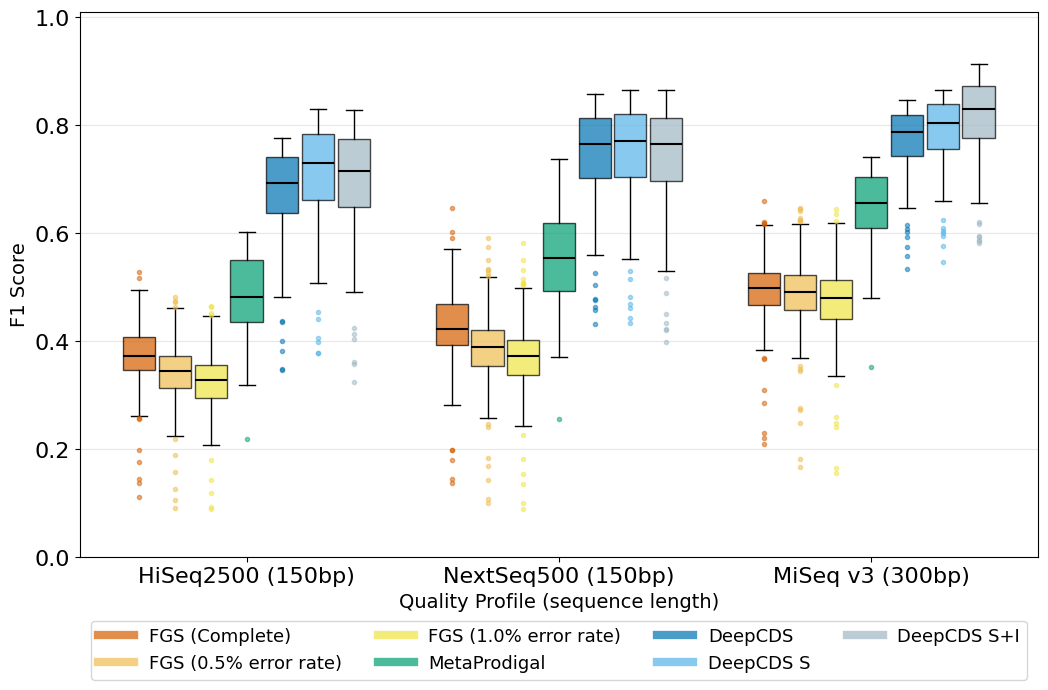

In [18]:
plot_codon_metric_boxplot(per_genome_metrics_list, platform_names,
                          'start_f1', 'F1 Score',
                          'start_codon_f1_by_platform_boxplot.svg')

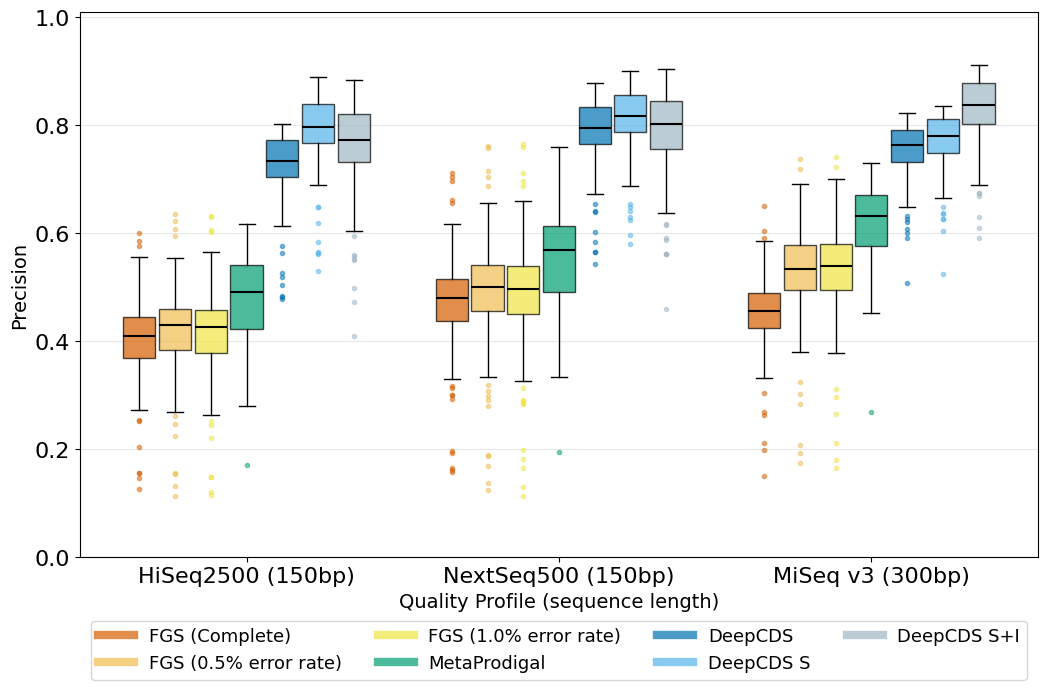

In [19]:
plot_codon_metric_boxplot(per_genome_metrics_list, platform_names,
                          'start_precision', 'Precision',
                          'start_codon_precision_by_platform_boxplot.svg')

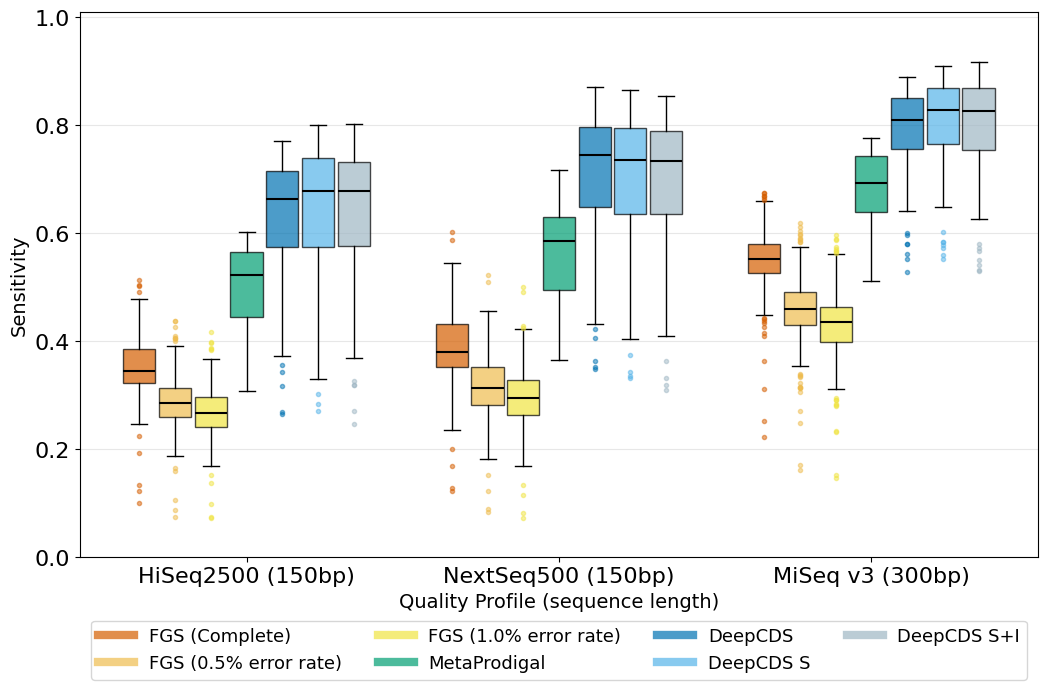

In [20]:
plot_codon_metric_boxplot(per_genome_metrics_list, platform_names,
                          'start_recall', 'Sensitivity',
                          'start_codon_recall_by_platform_boxplot.svg')

## Stop Codon Prediction

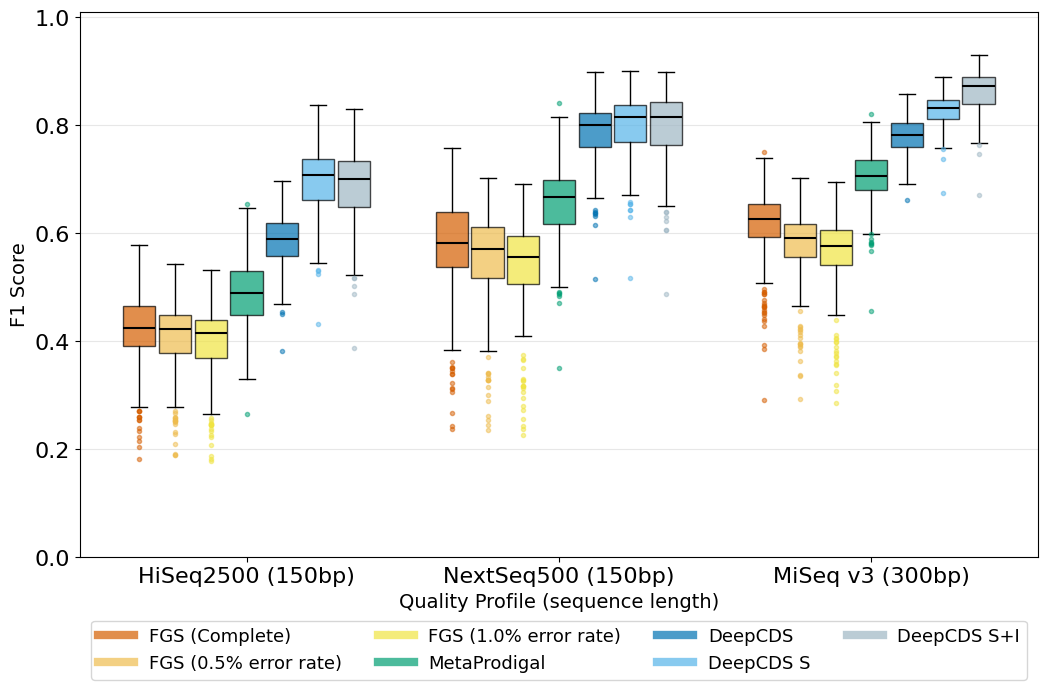

In [21]:
plot_codon_metric_boxplot(per_genome_metrics_list, platform_names,
                          'stop_f1', 'F1 Score',
                          'stop_codon_f1_by_platform_boxplot.svg')

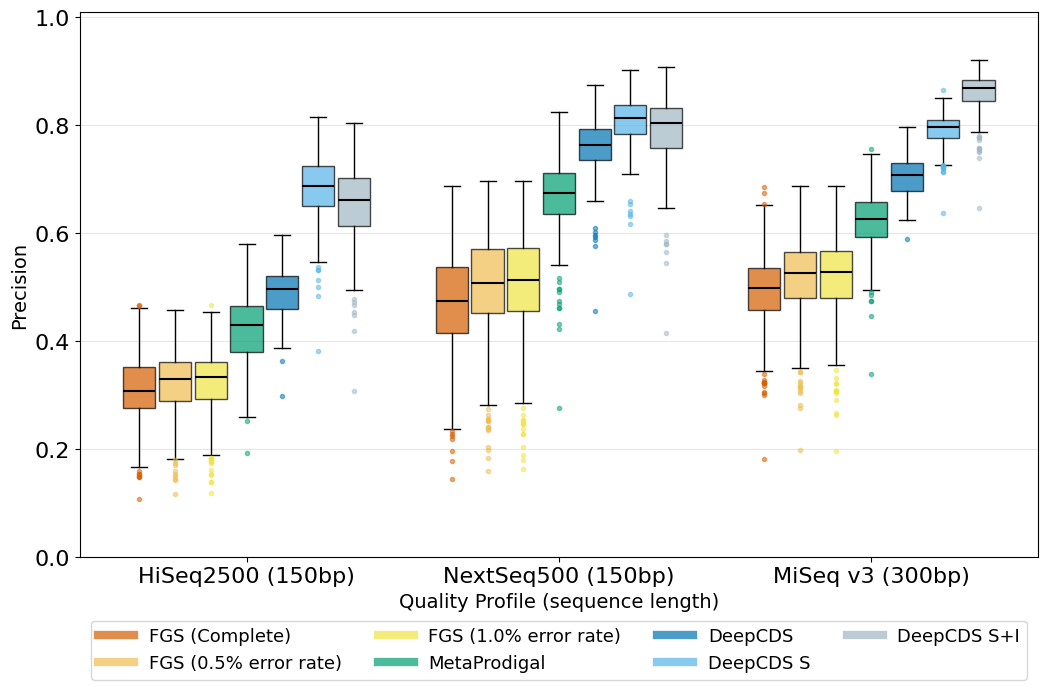

In [22]:
plot_codon_metric_boxplot(per_genome_metrics_list, platform_names,
                          'stop_precision', 'Precision',
                          'stop_codon_precision_by_platform_boxplot.svg')

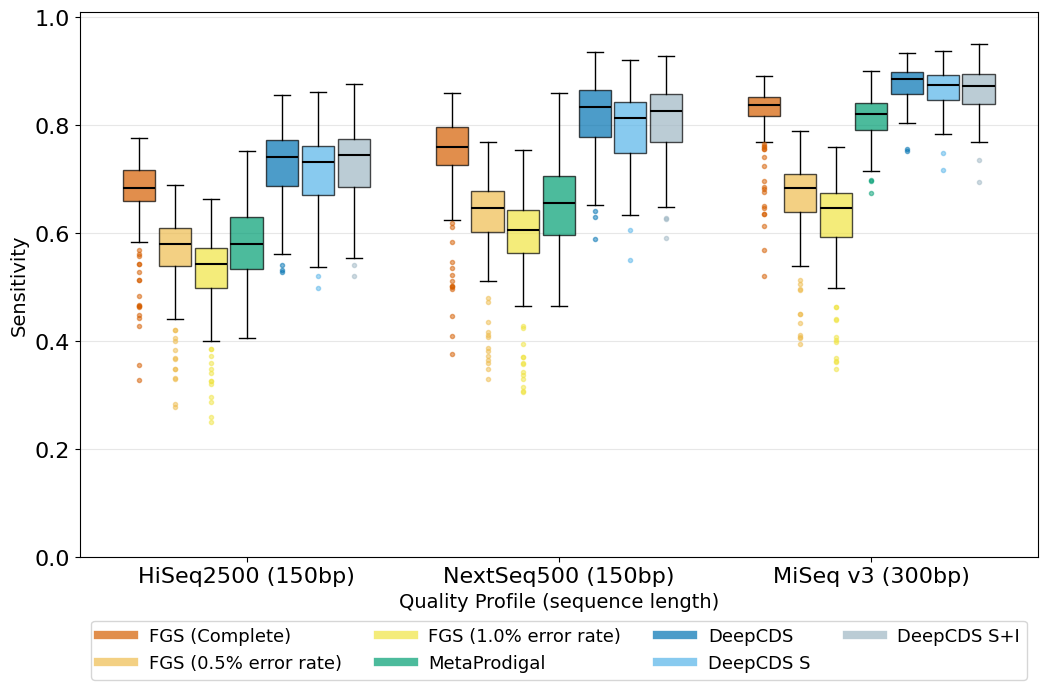

In [23]:
plot_codon_metric_boxplot(per_genome_metrics_list, platform_names,
                          'stop_recall', 'Sensitivity',
                          'stop_codon_recall_by_platform_boxplot.svg')

## Aggregated Metrics

In [25]:
def safe_div(a, b):
    return a / b if b > 0 else 0.0

metrics = {model: {
    'start_precision': [], 'start_recall': [], 'start_f1': [],
    'stop_precision':  [], 'stop_recall':  [], 'stop_f1':  [],
} for model in model_names}

for platform in platform_names:
    for model in model_names:
        if not has_data[platform][model]:
            for key in metrics[model]:
                metrics[model][key].append(np.nan)
            continue

        r = results[platform][model]

        s_prec = safe_div(r['start_tp'], r['start_tp'] + r['start_fp'])
        s_rec  = safe_div(r['start_tp'], r['start_tp'] + r['start_fn'])
        s_f1   = safe_div(2 * s_prec * s_rec, s_prec + s_rec)

        e_prec = safe_div(r['stop_tp'], r['stop_tp'] + r['stop_fp'])
        e_rec  = safe_div(r['stop_tp'], r['stop_tp'] + r['stop_fn'])
        e_f1   = safe_div(2 * e_prec * e_rec, e_prec + e_rec)

        metrics[model]['start_precision'].append(s_prec)
        metrics[model]['start_recall'].append(s_rec)
        metrics[model]['start_f1'].append(s_f1)
        metrics[model]['stop_precision'].append(e_prec)
        metrics[model]['stop_recall'].append(e_rec)
        metrics[model]['stop_f1'].append(e_f1)


## LaTeX Table

In [27]:
table_metrics = [
    ('start_f1',        'Start Codon F1'),
    ('start_precision', 'Start Codon Precision'),
    ('start_recall',    'Start Codon Sensitivity'),
    ('stop_f1',         'Stop Codon F1'),
    ('stop_precision',  'Stop Codon Precision'),
    ('stop_recall',     'Stop Codon Sensitivity'),
]

col_fmt = 'l' + 'c' * len(platform_names)
header_cols = ' & '.join([platform_display_names[p] for p in platform_names])

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
lines.append(r'\toprule')
lines.append(f'Model & {header_cols} \\\\')

for metric_key, metric_label in table_metrics:
    lines.append(r'\midrule')
    lines.append(rf'\multicolumn{{{1 + len(platform_names)}}}{{l}}{{\textbf{{{metric_label}}}}} \\\\')
    lines.append(r'\midrule')

    best_per_platform = []
    for i in range(len(platform_names)):
        col_vals = [metrics[model][metric_key][i] for model in model_names]
        valid = [v for v in col_vals if not np.isnan(v)]
        best_per_platform.append(max(valid) if valid else None)

    for model in model_names:
        display = MODEL_DISPLAY_NAMES[model]
        vals = []
        for i in range(len(platform_names)):
            v = metrics[model][metric_key][i]
            if np.isnan(v):
                vals.append('--')
            elif best_per_platform[i] is not None and v == best_per_platform[i]:
                vals.append(rf'\textbf{{{v:.3f}}}')
            else:
                vals.append(f'{v:.3f}')
        lines.append(f'{display} & ' + ' & '.join(vals) + r' \\')

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\caption{TODO: WRITE CAPTION. Aggregated start/stop codon detection metrics across all test genomes for each platform.}')
lines.append(r'\label{tab:start_stop_codon_art_modern}')
lines.append(r'\end{table}')

print('\n'.join(lines))

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\toprule
Model & HiSeq2500 (150bp) & NextSeq500 (150bp) & MiSeq v3 (300bp) \\
\midrule
\multicolumn{4}{l}{\textbf{Start Codon F1}} \\\\
\midrule
FGS (Complete) & 0.374 & 0.424 & 0.495 \\
FGS (0.5% error rate) & 0.340 & 0.385 & 0.487 \\
FGS (1.0% error rate) & 0.324 & 0.368 & 0.473 \\
MetaProdigal & 0.495 & 0.558 & 0.658 \\
DeepCDS & 0.693 & 0.765 & 0.785 \\
DeepCDS S & \textbf{0.729} & \textbf{0.770} & 0.802 \\
DeepCDS S+I & 0.717 & 0.760 & \textbf{0.830} \\
\midrule
\multicolumn{4}{l}{\textbf{Start Codon Precision}} \\\\
\midrule
FGS (Complete) & 0.404 & 0.474 & 0.452 \\
FGS (0.5% error rate) & 0.425 & 0.499 & 0.530 \\
FGS (1.0% error rate) & 0.422 & 0.495 & 0.533 \\
MetaProdigal & 0.486 & 0.554 & 0.629 \\
DeepCDS & 0.742 & 0.804 & 0.767 \\
DeepCDS S & \textbf{0.808} & \textbf{0.825} & 0.785 \\
DeepCDS S+I & 0.782 & 0.807 & \textbf{0.843} \\
\midrule
\multicolumn{4}{l}{\textbf{Start Codon Sensitivity}} \\\\
\midrule
FGS (Complete) & 0